# Graph Neural Network Topic Classifier

In the following we will focus on building a model for topic classification based on a Graph Neural Network approach.

In particular in the following we will show you how to:

* Create a TF-IDF representation of the corpus, that will be used as node features in the Graph Neural Network model 
* Build, train a Graph Neural Network model and identify the best threshold for classifying documents 
* Test the performance of the model in a out-of-sample tests, following a truly inductive approach 

**NOTE: This Notebook can only be run after the 01_nlp_graph_creation notebook, as some of the results computed in the first notebook will be here reused.**

### Load Dataset

In [1]:
import numpy as np
import pandas as pd

In [2]:
corpus = pd.read_pickle("corpus.p")

In [3]:
corpus.head()

,clean_text,label,language,parsed
id,,,,
test/14826,ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RI...,[trade],en,"(ASIAN, EXPORTERS, FEAR, DAMAGE, FROM, U.S.-JA..."
test/14828,CHINA DAILY SAYS VERMIN EAT 7-12 PCT GRAIN STO...,[grain],en,"(CHINA, DAILY, SAYS, VERMIN, EAT, 7, -, 12, PC..."
test/14829,JAPAN TO REVISE LONG-TERM ENERGY DEMAND DOWNWA...,"[crude, nat-gas]",en,"(JAPAN, TO, REVISE, LONG, -, TERM, ENERGY, DEM..."
test/14832,THAI TRADE DEFICIT WIDENS IN FIRST QUARTER Th...,"[corn, grain, rice, rubber, sugar, tin, trade]",en,"(THAI, TRADE, DEFICIT, WIDENS, IN, FIRST, QUAR..."
test/14833,INDONESIA SEES CPO PRICE RISING SHARPLY Indon...,"[palm-oil, veg-oil]",en,"(INDONESIA, SEES, CPO, PRICE, RISING, SHARPLY,..."


In [4]:
from collections import Counter
topics = Counter([label for document_labels in corpus["label"] for label in document_labels]).most_common(10)

In [5]:
topics

[('earn', 3964),
 ('acq', 2369),
 ('money-fx', 717),
 ('grain', 582),
 ('crude', 578),
 ('trade', 485),
 ('interest', 478),
 ('ship', 286),
 ('wheat', 283),
 ('corn', 237)]

In [6]:
topicsList = [topic[0] for topic in topics]
topicsSet = set(topicsList)
dataset = corpus[corpus["label"].apply(lambda x: len(topicsSet.intersection(x))>0)]

In [7]:
def get_labels(corpus, topicsList=topicsList):
    return corpus["label"].apply(
        lambda labels: pd.Series({label: 1 for label in labels}).reindex(topicsList).fillna(0)
    )[topicsList]

In [8]:
labels = get_labels(dataset)

In [9]:
labels.head()

,earn,acq,money-fx,grain,crude,trade,interest,ship,wheat,corn
id,,,,,,,,,,
test/14826,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
test/14828,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
test/14829,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
test/14832,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
test/14839,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [10]:
def get_features(corpus):
    return corpus["parsed"]

In [11]:
def get_features_and_labels(corpus):
    return get_features(corpus), get_labels(corpus)

In [12]:
def train_test_split(corpus):
    train_idx = [idx for idx in corpus.index if "training/" in idx]
    test_idx = [idx for idx in corpus.index if "test/" in idx]
    return corpus.loc[train_idx], corpus.loc[test_idx]

In [13]:
train, test = train_test_split(dataset)

In [14]:
def my_spacy_tokenizer(pos_filter=["NOUN", "VERB", "PROPN"]):
    def tokenizer(doc):
        return [token.lemma_ for token in doc if (pos_filter is None) or (token.pos_ in pos_filter)] 
    return tokenizer

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [16]:
cntVectorizer = TfidfVectorizer(
    analyzer=my_spacy_tokenizer(),
    max_df = 0.25, min_df = 2, max_features = 10000
)

In [17]:
trainFeatures, _ = get_features_and_labels(train)
testFeatures, _ = get_features_and_labels(test)


In [18]:
trainedTransformed = cntVectorizer.fit_transform(trainFeatures)
testTransformed = cntVectorizer.transform(testFeatures)

In [19]:
features = pd.concat([
    pd.DataFrame.sparse.from_spmatrix(trainedTransformed, index=trainFeatures.index), 
    pd.DataFrame.sparse.from_spmatrix(testTransformed, index=testFeatures.index)
])

In [20]:
features.shape

(9034, 10000)

Creating the Graph

In [21]:
from torch_geometric.data import HeteroData

In [22]:
edges = pd.read_pickle("bipartiteEdges.p")

In [23]:
entityTypes = {entity: ith for ith, entity in enumerate(edges["type"].unique())}

In [24]:
entityTypes

{'keywords': 0, 'GPE': 1, 'ORG': 2, 'PERSON': 3}

In [25]:
documentFeatures = features.loc[list(set(corpus.index).intersection(features.index))] #.assign(document=1, entity=0)

In [26]:
documentFeatures.head()

,0,1,2,3,4,5,6,7,8,9,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
id,,,,,,,,,,,,,,,,,,,,,
training/9139,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.023759,0.031614,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
training/2159,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
training/8026,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
training/4751,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
test/18564,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
entities = edges.groupby(["target", "type"])["source"].count().groupby(level=0).apply(
    lambda s: s.droplevel(0).reindex(entityTypes.keys()).fillna(0)
).unstack(level=1)

In [28]:
entityFeatures = (entities.T / entities.sum(axis=1)).T.assign(document=0, entity=1)

In [29]:
nodes = {"entity": entityFeatures, 
         "document": documentFeatures}

In [30]:
targets = labels.reindex(documentFeatures.index).fillna(0)

In [31]:
def train_test_split(corpus):
    graphIndex = [index for index in corpus.index]
    
    train_idx = [idx for idx in graphIndex if "training/" in idx]
    test_idx = [idx for idx in graphIndex if "test/" in idx]
    return corpus.loc[train_idx], corpus.loc[test_idx]

In [32]:
sampled, hold_out = train_test_split(targets)

In [33]:
from sklearn.model_selection import train_test_split

train, leftOut = train_test_split(
    sampled,
    train_size=0.1,
    random_state=42,
)

validation, test = train_test_split(
    leftOut, train_size=0.2, test_size=None, random_state=100,
)

In [34]:
train = train[train.sum(axis=1) > 0]
validation = validation[validation.sum(axis=1) > 0]
test = test[test.sum(axis=1) > 0]

In [75]:
print(f"Train: {train.shape}")
print(f"Validation: {validation.shape}")
print(f"Test: {test.shape}")

Train: (648, 10)
Validation: (1168, 10)
Test: (4673, 10)


In [36]:
docs_maps = {k: ith for ith, k in enumerate(documentFeatures.index)}

In [37]:
ents_maps = {k: ith for ith, k in enumerate(entityFeatures.index)}

In [38]:
labs_maps = {k: ith for ith, k in enumerate(labels.columns)}

In [39]:
edges["source_id"] = edges["source"].apply(lambda x: docs_maps.get(x, -1))
edges["target_id"] = edges["target"].apply(lambda x: ents_maps.get(x, -1))

In [40]:
import torch
import torch_sparse

def df_to_torch(df: pd.DataFrame):
    try:
        # @amarzullo: needs to be torch_sparse coo
        coo = df.sparse_to_coo()
        return torch_sparse.coalesce(coo.coords, coo.data, coo.shape)
        #coo = df.sparse.to_coo()
        #return torch.sparse_coo_tensor(coo.coords, coo.data, coo.shape) #.to_sparse_csr()
    except AttributeError:
        return torch.from_numpy(df.values)

In [41]:
data = HeteroData()

data["document"].x = df_to_torch(documentFeatures)#.to_dense() #@amarzullo to_dense
data["entity"].x = df_to_torch(entityFeatures)#.to_dense() #@amarzullo to_dense

In [42]:
for _type, group in edges[(edges["source_id"]!=-1) * (edges["target_id"]!=-1)].groupby("type"):
    data[("document", _type, "entity")].edge_index = df_to_torch(group[["source_id", "target_id"]].T)

In [96]:
data["document"].y = df_to_torch(targets).to(torch.float)

In [98]:
data["document"]["train_mask"] = df_to_torch(train.sum(axis=1).reindex(documentFeatures.index).fillna(0)).to(torch.bool)
data["document"]["val_mask"] = df_to_torch(validation.sum(axis=1).reindex(documentFeatures.index).fillna(0)).to(torch.bool)
data["document"]["test_mask"] = df_to_torch(test.sum(axis=1).reindex(documentFeatures.index).fillna(0)).to(torch.bool)

In [99]:
data

HeteroData(
  document={
    x=[9034, 10000],
    y=[9034, 10],
    train_mask=[9034],
    val_mask=[9034],
    test_mask=[9034],
  },
  entity={ x=[15143, 6] },
  (document, GPE, entity)={ edge_index=[2, 3141] },
  (document, ORG, entity)={ edge_index=[2, 4275] },
  (document, PERSON, entity)={ edge_index=[2, 1414] },
  (document, keywords, entity)={ edge_index=[2, 78828] },
  (entity, rev_GPE, document)={ edge_index=[2, 3141] },
  (entity, rev_ORG, document)={ edge_index=[2, 4275] },
  (entity, rev_PERSON, document)={ edge_index=[2, 1414] },
  (entity, rev_keywords, document)={ edge_index=[2, 78828] },
  (document, rev_rev_GPE, entity)={ edge_index=[2, 3141] },
  (document, rev_rev_ORG, entity)={ edge_index=[2, 4275] },
  (document, rev_rev_PERSON, entity)={ edge_index=[2, 1414] },
  (document, rev_rev_keywords, entity)={ edge_index=[2, 78828] }
)

In [100]:
import torch_geometric.transforms as T

In [101]:
data = T.ToUndirected()(data)

In [117]:
from torch_geometric.nn import SAGEConv, to_hetero
import torch.nn.functional as F

class GNN(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv((-1, -1), hidden_channels)
        self.conv2 = SAGEConv((-1, -1), out_channels)

    def forward(self, x, edge_index):
        x = x.float() #@amarzullo
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return F.sigmoid(x)


model = GNN(hidden_channels=64, out_channels=len(labs_maps))
model = to_hetero(model, data.metadata(), aggr='sum')

In [118]:
with torch.no_grad():  # Initialize lazy modules.
    out = model(data.x_dict, data.edge_index_dict)

In [119]:
device = torch.device("cpu")

model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [120]:
from dataclasses import dataclass

@dataclass
class Accuracy:
    correct: int
    total: int

    @property
    def score(self):
        return float(self.correct) * 1.0 / self.total

    def __add__(self, other: 'Accuracy'):
        if not isinstance(other, Accuracy):
            raise ValueError("Cannot add objects other than Accuracy")

        return Accuracy(self.correct+other.correct, self.total+other.total)

In [143]:
def score(correct):
    return Accuracy(int(correct.sum()), int(np.prod(correct.shape)))

In [144]:
def training(data, train_mask):
    model.train()

    # zero the parameter gradients
    optimizer.zero_grad()

    out = model(data.x_dict, data.edge_index_dict)
        
    loss = F.binary_cross_entropy(out['document'][train_mask], data['document'].y[train_mask])
    loss.backward()
    optimizer.step()

    return float(loss)

@torch.no_grad()
def eval(data, mask):
     # Test/Evaluate
    model.eval()

    out = model(data.x_dict, data.edge_index_dict)["document"][mask]

    pred = (1.0*(out>0.5) == data["document"].y[mask])
    
    return score(pred)

In [145]:
train_mask = data['document'].train_mask
val_mask = data['document'].val_mask

for epoch in range(10):  # loop over the dataset multiple times

    loss = training(data, train_mask)
        
    # Test/Evaluate
    train_score, val_score = eval(data, train_mask), eval(data, val_mask)

    print(f"Epoch {epoch} => Training: {train_score.score} Validation: {val_score.score}")

Epoch 0 => Training: 0.9237654320987654 Validation: 0.9208904109589041
Epoch 1 => Training: 0.941358024691358 Validation: 0.9183219178082191
Epoch 2 => Training: 0.961574074074074 Validation: 0.929195205479452
Epoch 3 => Training: 0.9657407407407408 Validation: 0.936472602739726
Epoch 4 => Training: 0.975 Validation: 0.9476027397260274
Epoch 5 => Training: 0.979320987654321 Validation: 0.9526541095890411
Epoch 6 => Training: 0.9847222222222223 Validation: 0.9537671232876712
Epoch 7 => Training: 0.9895061728395061 Validation: 0.9533390410958904
Epoch 8 => Training: 0.9922839506172839 Validation: 0.9555650684931507
Epoch 9 => Training: 0.9942901234567901 Validation: 0.958904109589041


### With batches

In [57]:
from torch_geometric.loader import NeighborLoader

In [58]:
train_input_nodes = ('document', data['document'].train_mask)
val_input_nodes = ('document', data['document'].val_mask)
kwargs = {'batch_size': 128, 'num_workers': 6, 'persistent_workers': True}

In [59]:
train_loader = NeighborLoader(data, num_neighbors=[10] * 2, shuffle=True,
                                  input_nodes=train_input_nodes, **kwargs)
val_loader = NeighborLoader(data, num_neighbors=[10] * 2,
                                input_nodes=val_input_nodes, **kwargs)

In [295]:
for epoch in range(1):
    loss = 0
    for nth, batch in enumerate(train_loader):
        batch_size = batch['document'].batch_size
        train_mask = range(batch_size)
        loss += training(batch, train_mask)*batch_size

    # Training error
    train_score = Accuracy(0, 0)
    for nth, batch in enumerate(train_loader):
        batch_size = batch['document'].batch_size
        train_mask = range(batch_size)
        train_score += eval(batch, train_mask)

    val_score = Accuracy(0, 0)
    for nth, batch in enumerate(val_loader):
        batch_size = batch['document'].batch_size
        train_mask = range(batch_size)
        val_score += eval(batch, train_mask)
    
    print(f"Epoch {epoch} => Loss: {loss} Train: {train_score.score} Val: {val_score.score}")

Epoch 0 => Loss: 3.9227377609213363 Train: 0.9969135802469136 Val: 0.8330479452054794


### Threshold identification

In [146]:
test_input_nodes = ('document', data['document'].test_mask)
kwargs = {'batch_size': 128, 'num_workers': 6, 'persistent_workers': True}

In [147]:
test_loader = NeighborLoader(data, num_neighbors=[10] * 2, input_nodes=test_input_nodes, **kwargs)

In [187]:
@torch.no_grad()
def get_output(data, mask):
     # Test/Evaluate
    model.eval()

    out = model(data.x_dict, data.edge_index_dict)["document"][mask]

    return pd.DataFrame(out)

def reindex(df, indices):
    df.index = indices
    return df

In [188]:
def remap_index(df, docs_maps, labs_maps):
    inv_docs_maps = {v:k for k, v in docs_maps.items()}
    inv_labs_maps = {v:k for k, v in labs_maps.items()}
    
    df.index = [inv_docs_maps[x] for x in df.index]
    df.columns = [inv_labs_maps[x] for x in df.columns]
    return df

In [192]:
preds = []
for nth, batch in enumerate(test_loader):
    batch_size = batch['document'].batch_size
    train_mask = range(batch_size)
    preds.append(
        remap_index(
            reindex(
                get_output(batch, train_mask), 
                batch["document"].input_id.tolist()
            ),
            docs_maps,
            labs_maps
        )
    )

In [196]:
test_predictions = pd.concat(preds)

In [197]:
test_results = pd.concat({
    "target": test, 
    "preds": test_predictions
}, axis=1)

In [199]:
from sklearn.metrics import f1_score, classification_report

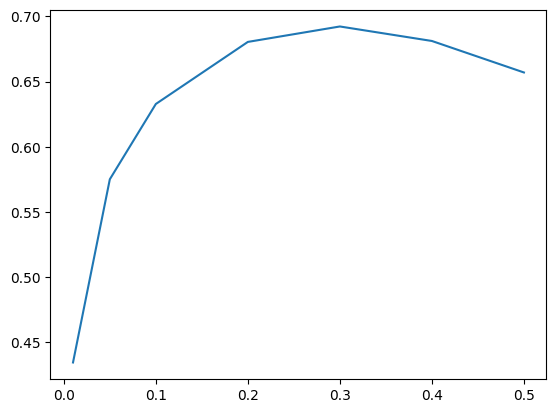

In [200]:
f1s = {}

for th in [0.01,0.05,0.1,0.2,0.3,0.4,0.5]:
    f1s[th] = f1_score(test_results["target"], 1.0*(test_results["preds"]>th), average="macro")
    
pd.Series(f1s).plot()

In [201]:
print(classification_report(test_results["target"], 1.0*(test_results["preds"]>0.2)))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94      2106
           1       0.94      0.86      0.90      1163
           2       0.70      0.91      0.79       380
           3       0.63      0.96      0.76       312
           4       0.75      0.62      0.68       290
           5       0.89      0.57      0.69       254
           6       0.57      0.63      0.60       250
           7       0.31      0.66      0.42       145
           8       0.40      0.91      0.55       148
           9       0.33      0.86      0.47       126

   micro avg       0.77      0.85      0.81      5174
   macro avg       0.65      0.79      0.68      5174
weighted avg       0.83      0.85      0.83      5174
 samples avg       0.80      0.86      0.82      5174



/home/deusebio/.pyenv/versions/graph-machine-learning/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
